# Porównanie cech melodyczno-rytmicznych w ujęciu biocybernetycznym

Zgodnie z postulatem Mitasa (2010), obiektywizacja wpływu muzyki na człowieka wymaga kwantyfikacji jej parametrów fizykalnych. Niniejsza praca przedstawia automatyczną ekstrakcję cech melodyczno-rytmicznych z plików MIDI, ze szczególnym uwzględnieniem parametrów istotnych dla efektu entrainmentu (Thaut, 2013) oraz potencjalnych zastosowań w Rhythmic Auditory Stimulation. Wyznaczone wektory cech mogą stanowić podstawę adaptacyjnego generatora pobudzeń w systemach kansei engineering.

Analiza traktuje plik MIDI jako mierzalny opis bodźca muzycznego: tempo, stabilność tempa, regularność odstępów między onsetami oraz cechy konturu melodycznego są przekształcane do wspólnego wektora cech. Taki opis pozwala porównać utwory nie tylko estetycznie, ale także funkcjonalnie, z punktu widzenia potencjalnego zastosowania terapeutycznego.

## Hipoteza i korpus

Hipoteza: klastrowanie aglomeracyjne na wektorach cech melodyczno-rytmicznych, z włączeniem `bpm_mean`, `tempo_stability` oraz `ioi_cv`, powinno rozdzielić utwory na trzy grupy zgodne z apriorycznym podziałem terapeutycznym.

Korpus podzielono na trzy grupy:

- **Grupa A - chód/RAS**: utwory o regularnym pulsie, oczekiwanym tempie około 100-120 BPM i potencjalnej użyteczności dla synchronizacji ruchu.
- **Grupa B - relaksacja**: utwory wolniejsze, o niższej gęstości zdarzeń i potencjalnie mniejszym obciążeniu poznawczym.
- **Grupa C - złożoność kognitywna**: utwory o niestandardowym metrum, zmiennych sekcjach lub zwiększonej złożoności rytmiczno-formalnej.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pretty_midi
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

from melody import (
    build_rolls,
    compute_entrainment_suitability,
    compute_feature_vector,
    compute_highest_per_instrument,
    fold_bpm_to_band,
    pad_rolls,
    segment_phrases,
    track_lead_voice,
)

FS = 100
MIN_NOTES = 10
MIN_PITCH = 48
MIN_ENERGY_PER_FRAME = 10
SWITCH_N = 3
MIN_REST_BEATS = 2
MIN_PHRASE_NOTES = 4

CORPUS = [
    {"title": "Stayin' Alive", "category": "RAS/chod", "path": "music/Bee_Gees_Stayin_Alive.mid"},
    {"title": "Eye of the Tiger", "category": "RAS/chod", "path": "music/Survivor_Eye_of_the_Tiger.mid"},
    {"title": "Stars and Stripes Forever", "category": "RAS/chod", "path": "music/Sousa_Stars_and_Stripes_Forever.mid"},
    {"title": "Radetzky March", "category": "RAS/chod", "path": "music/Strauss_Radetzky_March.mid"},
    {"title": "Pomp and Circumstance", "category": "RAS/chod", "path": "music/Elgar_Pomp_and_Circumstance.mid"},
    {"title": "Gymnopedie No. 1", "category": "relaksacja", "path": "music/Satie_Gymnopedie_No_1.mid"},
    {"title": "Clair de Lune", "category": "relaksacja", "path": "music/Debussy_Clair_de_Lune.mid"},
    {"title": "Canon in D", "category": "relaksacja", "path": "music/Pachelbel_Canon_in_D.mid"},
    {"title": "Moonlight Sonata I", "category": "relaksacja", "path": "music/Beethoven_Moonlight_Sonata_1.mid"},
    {"title": "Nocturne Op. 9 No. 2", "category": "relaksacja", "path": "music/Chopin_Nocturne_Op_9_No_2.mid"},
    {"title": "Bohemian Rhapsody", "category": "zlozona", "path": "music/Queen_Bohemian_Rhapsody.mid"},
    {"title": "Take Five", "category": "zlozona", "path": "music/Brubeck_Take_Five.mid"},
    {"title": "Money", "category": "zlozona", "path": "music/Pink_Floyd_Money.mid"},
    {"title": "21st Century Schizoid Man", "category": "zlozona", "path": "music/King_Crimson_21st_Century_Schizoid_Man.mid"},
    {"title": "Paranoid Android", "category": "zlozona", "path": "music/Radiohead_Paranoid_Android.mid"},
]

missing = [item["path"] for item in CORPUS if not os.path.exists(item["path"])]
if missing:
    raise FileNotFoundError("Brakujące pliki MIDI: " + ", ".join(missing))

In [2]:
def run_pipeline(path):
    utwor = pretty_midi.PrettyMIDI(path)
    beats = utwor.get_beats()
    beat_frames = (beats * FS).astype(int)

    rolls, instruments = build_rolls(utwor, fs=FS, min_notes=MIN_NOTES)
    if not rolls:
        raise ValueError(f"Brak wystarczająco gęstych nieperkusyjnych ścieżek w {path}")

    padded, max_len = pad_rolls(rolls)
    beat_frames_clipped = np.clip(beat_frames, 0, max_len)
    n_windows = len(beat_frames_clipped) - 1
    n_inst = len(instruments)
    if n_windows <= 0:
        raise ValueError(f"Nie udało się wyznaczyć okien beatowych dla {path}")

    highest = compute_highest_per_instrument(
        padded,
        beat_frames_clipped,
        MIN_PITCH,
        MIN_ENERGY_PER_FRAME,
    )
    _, lead_pitch = track_lead_voice(highest, n_windows, n_inst, SWITCH_N)
    phrases = segment_phrases(lead_pitch, min_rest_beats=MIN_REST_BEATS)
    phrases = [p for p in phrases if len(p) >= MIN_PHRASE_NOTES]
    return utwor, lead_pitch, phrases


results = {}
for item in CORPUS:
    utwor, lead_pitch, phrases = run_pipeline(item["path"])
    results[item["title"]] = {
        "category": item["category"],
        "path": item["path"],
        "features": compute_feature_vector(lead_pitch, phrases, utwor),
        "active_beats": sum(1 for p in lead_pitch if p is not None),
        "n_beats": len(lead_pitch),
        "n_phrases": len(phrases),
    }
    print(
        f"{item['title']:<28} | {item['category']:<10} | "
        f"{len(lead_pitch):>4} beatów | "
        f"{results[item['title']]['active_beats']:>4} aktywnych | "
        f"{len(phrases):>2} fraz"
    )


Stayin' Alive                | RAS/chod   |  500 beatów |  449 aktywnych | 10 fraz
Eye of the Tiger             | RAS/chod   |  428 beatów |  346 aktywnych | 15 fraz
Stars and Stripes Forever    | RAS/chod   |  311 beatów |  304 aktywnych |  2 fraz


Radetzky March               | RAS/chod   |  506 beatów |  477 aktywnych |  6 fraz


/Users/hxwk/melodic_analysis_toolbox/.venv/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Pomp and Circumstance        | RAS/chod   |  630 beatów |  571 aktywnych | 18 fraz
Gymnopedie No. 1             | relaksacja |  233 beatów |  188 aktywnych |  4 fraz
Clair de Lune                | relaksacja |  212 beatów |  212 aktywnych |  1 fraz


Canon in D                   | relaksacja |  459 beatów |  451 aktywnych |  2 fraz
Moonlight Sonata I           | relaksacja |  275 beatów |  268 aktywnych |  2 fraz
Nocturne Op. 9 No. 2         | relaksacja |  145 beatów |  137 aktywnych |  2 fraz


Bohemian Rhapsody            | zlozona    |  484 beatów |  447 aktywnych | 10 fraz


Take Five                    | zlozona    |  410 beatów |  302 aktywnych | 12 fraz


Money                        | zlozona    |  818 beatów |  535 aktywnych | 35 fraz
21st Century Schizoid Man    | zlozona    |  474 beatów |  434 aktywnych | 10 fraz


Paranoid Android             | zlozona    |  541 beatów |  484 aktywnych | 13 fraz


## Ekstrakcja cech

Poniższa tabela zawiera cechy melodyczne oraz rytmiczno-tempowe. Cechy BPM opisują tempo metryczne zapisane w MIDI, `tempo_stability` mierzy stabilność tempa, `notes_per_beat` opisuje gęstość onsetów względem beatu, a `ioi_cv` i `ioi_entropy` charakteryzują regularność odstępów między kolejnymi onsetami po deduplikacji zdarzeń równoczesnych. Dodatkowo `pulse_clarity` (wysokość szczytu autokorelacji obwiedni onsetów w paśmie pulsu) mierzy wyrazistość i regularność pulsu, `syncopation` — udział onsetów przypadających na słabe części taktu względem siatki beatów z hierarchią metryczną, a `form_complexity` — formalną niejednorodność utworu w czasie (średnia odległość między oknami w macierzy samopodobieństwa: niska dla utworu jednorodnego, wysoka dla wielosekcyjnego).

In [3]:
SCALAR_KEYS = [
    "interval_entropy",
    "melodic_redundancy",
    "step_leap_ratio",
    "pitch_range",
    "avg_phrase_length",
    "bpm_mean",
    "bpm_std",
    "tempo_stability",
    "notes_per_beat",
    "ioi_cv",
    "ioi_entropy",
    "pulse_clarity",
    "syncopation",
    "form_complexity",
]

names = [item["title"] for item in CORPUS]
header = f"{'Utwór':<28} {'Kategoria':<12}" + ''.join(f"{k:>20}" for k in SCALAR_KEYS)
print(header)
print('-' * len(header))
for name in names:
    row = f"{name:<28} {results[name]['category']:<12}"
    for key in SCALAR_KEYS:
        row += f"{results[name]['features'][key]:>20.3f}"
    print(row)

Utwór                        Kategoria       interval_entropy  melodic_redundancy     step_leap_ratio         pitch_range   avg_phrase_length            bpm_mean             bpm_std     tempo_stability      notes_per_beat              ioi_cv         ioi_entropy       pulse_clarity         syncopation     form_complexity
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Stayin' Alive                RAS/chod                   3.040               0.497               6.316              29.000              46.500             104.000               0.000               1.000               4.843               1.064               0.992               0.539               0.426               0.093
Eye of the Tiger             RAS/c

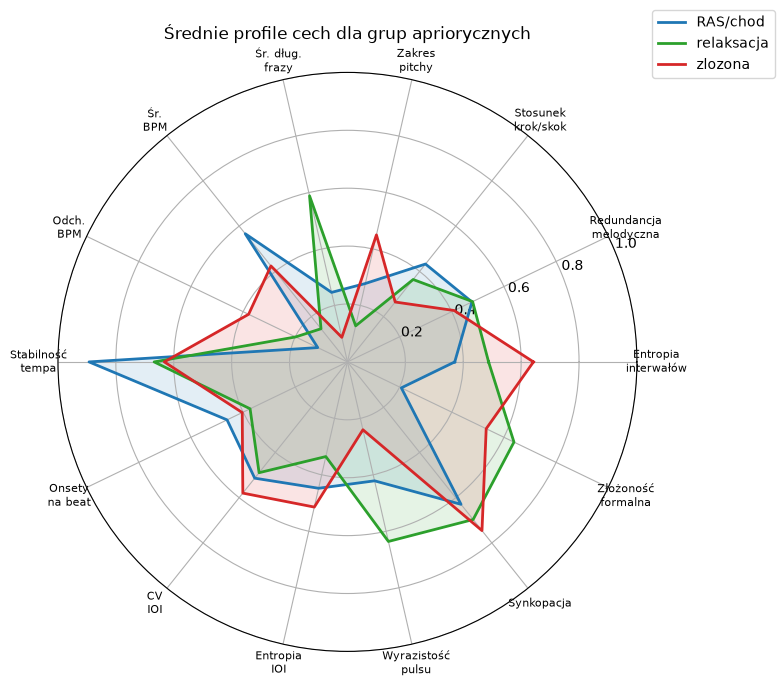

In [4]:
labels = [
    "Entropia\ninterwałów",
    "Redundancja\nmelodyczna",
    "Stosunek\nkrok/skok",
    "Zakres\npitchy",
    "Śr. dług.\nfrazy",
    "Śr.\nBPM",
    "Odch.\nBPM",
    "Stabilność\ntempa",
    "Onsety\nna beat",
    "CV\nIOI",
    "Entropia\nIOI",
    "Wyrazistość\npulsu",
    "Synkopacja",
    "Złożoność\nformalna",
]
category_order = ["RAS/chod", "relaksacja", "zlozona"]
category_colors = {
    "RAS/chod": "tab:blue",
    "relaksacja": "tab:green",
    "zlozona": "tab:red",
}

data = np.array([[results[name]["features"][k] for k in SCALAR_KEYS] for name in names])
mins = data.min(axis=0)
maxs = data.max(axis=0)
rng = np.where(maxs - mins == 0, 1, maxs - mins)
normed = (data - mins) / rng

n_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for category in category_order:
    idxs = [i for i, name in enumerate(names) if results[name]["category"] == category]
    values = normed[idxs].mean(axis=0).tolist()
    values += values[:1]
    ax.plot(angles, values, color=category_colors[category], linewidth=2, label=category)
    ax.fill(angles, values, color=category_colors[category], alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Średnie profile cech dla grup apriorycznych", pad=24)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.12))
plt.tight_layout()
plt.savefig("report/figures/radar.png", dpi=150, bbox_inches="tight")
plt.show()

## Klastrowanie aglomeracyjne na cechach rytmiczno-formalnych

Hipoteza dotyczy podziału **funkcjonalnego** (chód/RAS, relaksacja, złożoność), który zależy od rytmu i formy, a nie od tonacji czy konkretnej melodii. Dlatego do klastrowania używamy **wyłącznie podzbioru cech rytmiczno-formalnych**, a nie pełnego wektora cech z `feature_vector_to_array`. Pełny wektor zawiera m.in. 12-elementowy histogram klas wysokości, który koduje *tonację* utworu — po standaryzacji zdominowałby on odległość euklidesową i grupował utwory według tonacji, a nie według funkcji terapeutycznej.

Przed klastrowaniem składamy `bpm_mean` do pasma chodu funkcją `fold_bpm_to_band` (składanie metrycznych oktaw, ÷2). Tempo w MIDI jest zapisane na poziomie ćwierćnuty, więc utwory w metrum *alla breve* (marsze) raportują tempo dwukrotnie zawyżone — *Stars and Stripes* ~222 zamiast ~111 BPM. Składamy **tylko w dół**, żeby nie zawyżać utworów wolnych: dzięki temu wartość staje się interpretowalna jako kadencja kroków, a jednocześnie zachowana zostaje oś wolne↔szybkie, istotna dla materiału relaksacyjnego. Gęstość onsetów (`notes_per_beat`) skalujemy tym samym czynnikiem, bo wydłużenie beatu zmienia liczbę nut przypadających na beat.

Do wektora wchodzi **siedem cech**: `bpm_folded`, `notes_per_beat`, `ioi_cv`, `ioi_entropy`, `pulse_clarity`, `syncopation` oraz `form_complexity`. Każda jest uzasadniona **a priori**, a nie dobrana pod zgodność z etykietami: **pulse clarity** (autokorelacja obwiedni onsetów) mierzy wyrazistość pulsu — korelat skuteczności entrainmentu w RAS; **syncopation** — udział onsetów na słabych częściach taktu (złożoność rytmiczna); **form_complexity** — formalną niejednorodność w czasie (zmiany sekcji), czyli wymiar, którego cechy rytmiczne nie obejmują. Pomijamy `tempo_stability` oraz `bpm_std` jako prawie stałe w korpusie MIDI. Cechy standaryzujemy (`StandardScaler`), a dendrogram liczymy metodą Warda.

> **Uwaga metodologiczna.** Cechy dobieramy z przesłanek teoretycznych, a nie maksymalizując zgodność klastrów z etykietami — to świadoma ochrona przed dopasowaniem pipeline'u do tych 15 utworów (*researcher degrees of freedom*). Przy tak małej próbie wynik traktujemy jako **prototyp metody**; rzetelna walidacja (ARI, stabilność leave-one-out, większy korpus) jest osobnym, kolejnym krokiem.

In [5]:
RHYTHM_KEYS = [
    "bpm_folded", "notes_per_beat", "ioi_cv", "ioi_entropy",
    "pulse_clarity", "syncopation", "form_complexity",
]


def rhythm_features(features):
    """Podzbiór cech rytmiczno-formalnych: BPM złożone do pasma chodu + gęstość
    onsetów przeskalowana tym samym czynnikiem, regularność/entropia IOI,
    wyrazistość pulsu, synkopacja oraz złożoność formalna."""
    bpm = features["bpm_mean"]
    bpm_folded = fold_bpm_to_band(bpm)
    fold_factor = bpm / bpm_folded if bpm_folded > 0 else 1.0
    return {
        "bpm_folded": bpm_folded,
        "notes_per_beat": features["notes_per_beat"] * fold_factor,
        "ioi_cv": features["ioi_cv"],
        "ioi_entropy": features["ioi_entropy"],
        "pulse_clarity": features["pulse_clarity"],
        "syncopation": features["syncopation"],
        "form_complexity": features["form_complexity"],
    }


for name in names:
    results[name]["rhythm"] = rhythm_features(results[name]["features"])

X_rhythm = np.array([[results[name]["rhythm"][k] for k in RHYTHM_KEYS] for name in names])
X_rhythm_scaled = StandardScaler().fit_transform(X_rhythm)

clustering = AgglomerativeClustering(n_clusters=3, linkage="ward")
cluster_labels = clustering.fit_predict(X_rhythm_scaled)
for name, cluster in zip(names, cluster_labels):
    results[name]["cluster"] = int(cluster)

print(f"{'Utwór':<28}{'BPM zł.':>9}{'Puls':>7}{'Synkop':>8}{'Forma':>8}{'Klaster':>9}")
print('-' * 69)
for name in names:
    r = results[name]["rhythm"]
    print(
        f"{name:<28}"
        f"{r['bpm_folded']:>9.1f}"
        f"{r['pulse_clarity']:>7.2f}"
        f"{r['syncopation']:>8.2f}"
        f"{r['form_complexity']:>8.2f}"
        f"{results[name]['cluster']:>9}"
    )

print("\nTabela zgodności: kategoria aprioryczna vs. klaster algorytmu")
cluster_ids = sorted(set(cluster_labels))
header = f"{'Kategoria':<14}" + ''.join(f"cluster {cluster:>2}".rjust(12) for cluster in cluster_ids)
print(header)
print('-' * len(header))
for category in category_order:
    counts = Counter(
        results[name]["cluster"]
        for name in names
        if results[name]["category"] == category
    )
    row = f"{category:<14}" + ''.join(f"{counts.get(cluster, 0):>12}" for cluster in cluster_ids)
    print(row)

Utwór                         BPM zł.   Puls  Synkop   Forma  Klaster
---------------------------------------------------------------------
Stayin' Alive                   104.0   0.54    0.43    0.09        0
Eye of the Tiger                119.0   0.59    0.37    0.14        1
Stars and Stripes Forever       110.8   0.68    0.22    0.10        1
Radetzky March                   95.0   0.47    0.12    0.11        2
Pomp and Circumstance            89.7   0.56    0.29    0.19        0
Gymnopedie No. 1                 90.0   0.75    0.01    0.19        1
Clair de Lune                    83.2   0.52    0.45    0.24        0
Canon in D                       77.0   0.87    0.27    0.15        1
Moonlight Sonata I               44.6   0.89    0.44    0.18        1
Nocturne Op. 9 No. 2             57.9   0.41    0.40    0.21        0
Bohemian Rhapsody               103.3   0.66    0.33    0.25        0
Take Five                        84.0   0.34    0.30    0.14        0
Money               

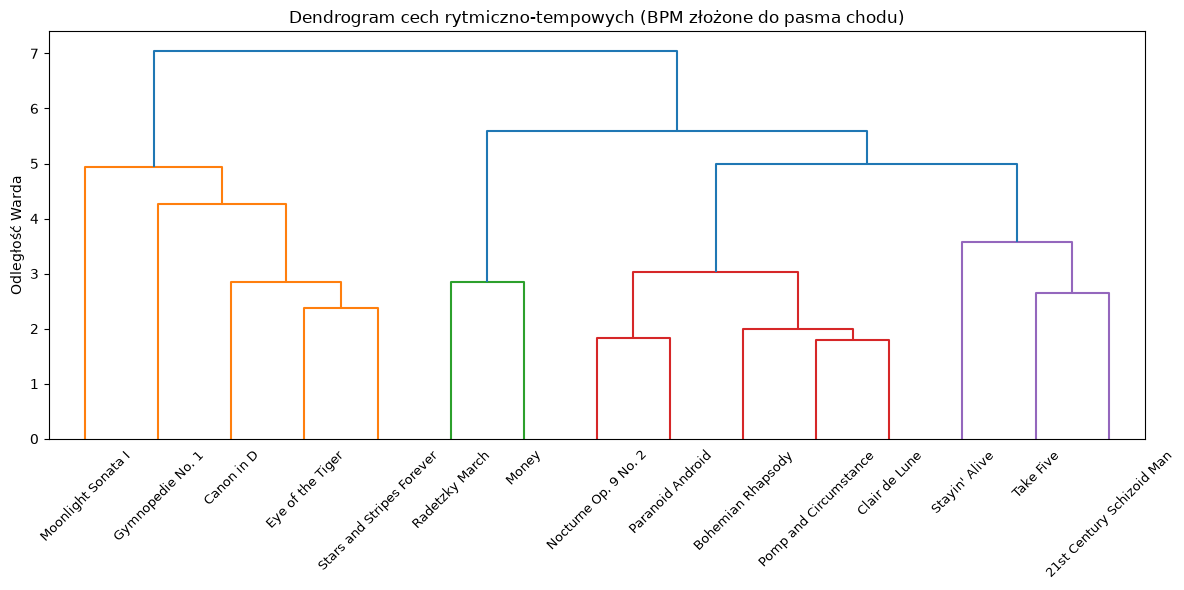

In [6]:
Z = linkage(X_rhythm_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=names, leaf_rotation=45, leaf_font_size=9)
plt.title("Dendrogram cech rytmiczno-tempowych (BPM złożone do pasma chodu)")
plt.ylabel("Odległość Warda")
plt.tight_layout()
plt.savefig("report/figures/dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

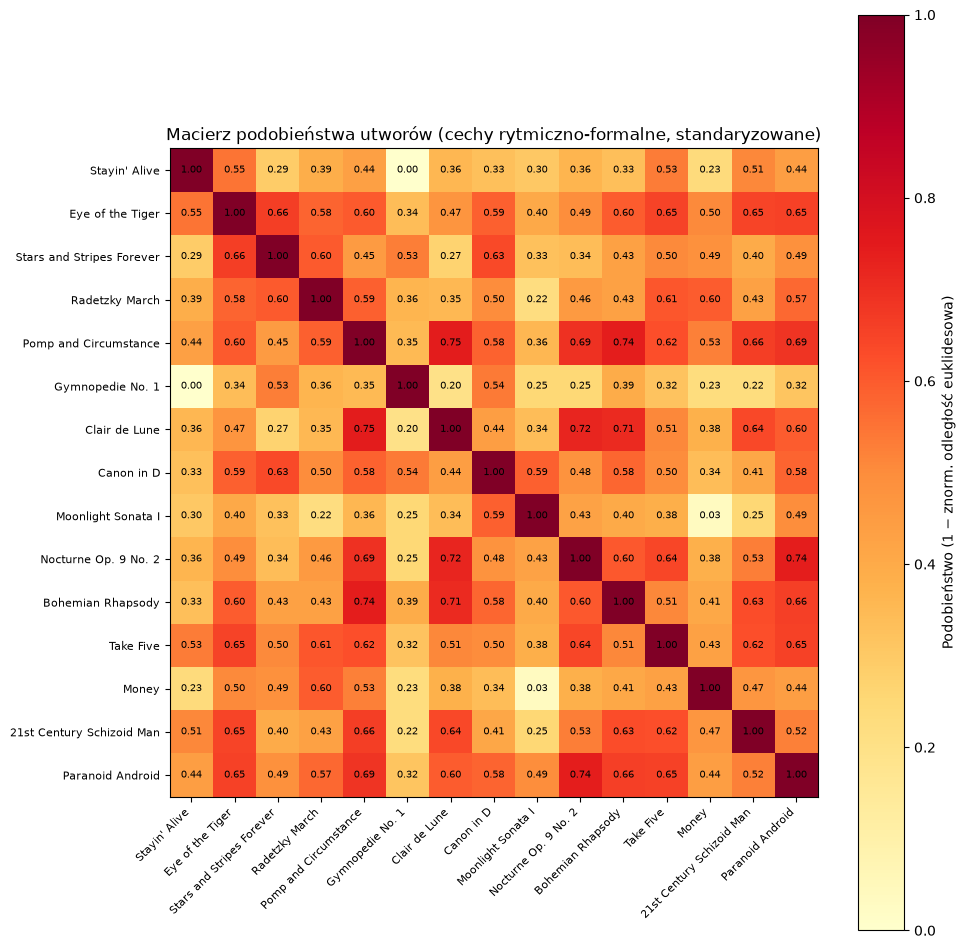

In [7]:
# Podobieństwo liczymy w tej samej przestrzeni co klasteryzacja: odległość
# euklidesowa na cechach standaryzowanych, przeskalowana do podobieństwa w [0,1].
# (Cosinus na cechach surowych byłby zdominowany przez bpm_folded — rząd ~100
# wobec pozostałych cech <= ~5 — i dawałby ~1 wszędzie.)
dist = np.sqrt(((X_rhythm_scaled[:, None, :] - X_rhythm_scaled[None, :, :]) ** 2).sum(axis=-1))
sim_matrix = 1.0 - dist / dist.max()

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Podobieństwo (1 − znorm. odległość euklidesowa)")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Macierz podobieństwa utworów (cechy rytmiczno-formalne, standaryzowane)")
plt.tight_layout()
plt.savefig("report/figures/similarity.png", dpi=150, bbox_inches="tight")
plt.show()

## Przydatność do Rhythmic Auditory Stimulation (RAS)

Klastrowanie pokazało, jakie wymiary cech istnieją w korpusie. Teraz wykorzystujemy je do bezpośredniej odpowiedzi na **temat 9** — które utwory nadają się jako bodziec RAS wspomagający chód.

Wskaźnik `compute_entrainment_suitability` łączy **a priori** trzy warunki, które literatura RAS (Thaut, Murgia) wiąże ze skutecznym entrainmentem motorycznym, jako ich średnią geometryczną (porażka na którymkolwiek wymiarze obniża cały wynik):

- **dopasowanie kadencji** — tempo złożone do pasma komfortowej kadencji chodu (~90–130 kroków/min), z liniowym spadkiem poza pasmem;
- **wyrazistość pulsu** (`pulse_clarity`) — wyraźny, regularny puls, do którego można zsynchronizować krok;
- **przewidywalność** (`1 − syncopation`) — onsety na mocnych częściach taktu.

Progi klas („dobry / warunkowy / nieodpowiedni") są **ilustracyjne**, nie klinicznymi punktami odcięcia — służą tylko czytelności rankingu. Wskaźnik mierzy *entrainowalność pulsu*, a nie pobudzenie/energię, więc spokojny, ale regularny utwór może wypaść wysoko.

Utwór                       Kategoria    Suitability  Ocena RAS (progi ilustracyjne)
--------------------------------------------------------------------------------
Gymnopedie No. 1            relaksacja         0.906  dobry kandydat
Stars and Stripes Forever   RAS/chod           0.811  dobry kandydat
Bohemian Rhapsody           zlozona            0.764  dobry kandydat
Radetzky March              RAS/chod           0.745  dobry kandydat
Pomp and Circumstance       RAS/chod           0.734  dobry kandydat
Eye of the Tiger            RAS/chod           0.720  dobry kandydat
Canon in D                  relaksacja         0.712  dobry kandydat
Stayin' Alive               RAS/chod           0.677  warunkowy
Money                       zlozona            0.652  warunkowy
21st Century Schizoid Man   zlozona            0.635  warunkowy
Clair de Lune               relaksacja         0.606  warunkowy
Paranoid Android            zlozona            0.577  warunkowy
Take Five                   zlo

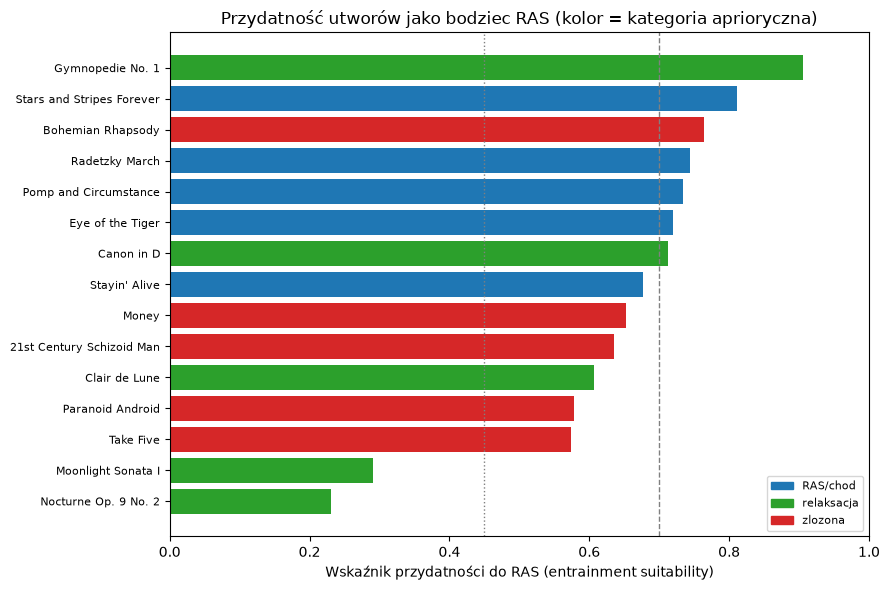

In [8]:
suitability = {
    name: compute_entrainment_suitability(results[name]["features"]) for name in names
}


def ras_band(score):
    if score >= 0.70:
        return "dobry kandydat"
    if score >= 0.45:
        return "warunkowy"
    return "nieodpowiedni"


ranked = sorted(names, key=lambda n: suitability[n], reverse=True)
print(f"{'Utwór':<28}{'Kategoria':<12}{'Suitability':>12}  Ocena RAS (progi ilustracyjne)")
print('-' * 80)
for name in ranked:
    print(
        f"{name:<28}{results[name]['category']:<12}"
        f"{suitability[name]:>12.3f}  {ras_band(suitability[name])}"
    )

order = ranked[::-1]
vals = [suitability[n] for n in order]
colors = [category_colors[results[n]["category"]] for n in order]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(order)), vals, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("Wskaźnik przydatności do RAS (entrainment suitability)")
ax.axvline(0.70, ls="--", c="gray", lw=1)
ax.axvline(0.45, ls=":", c="gray", lw=1)
ax.set_title("Przydatność utworów jako bodziec RAS (kolor = kategoria aprioryczna)")
handles = [Patch(color=category_colors[c], label=c) for c in category_order]
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("report/figures/ras_suitability.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja kontrastowych przypadków

Wskaźnik dobrze ilustruje, że przydatność do RAS to **iloczyn** trzech niezależnych warunków — wystarczy, że jeden zawiedzie, by utwór odpadł:

- **Stars and Stripes Forever** (≈0.81) — *idealny kandydat*. Tempo składa się do ~111 BPM (środek pasma kadencji), puls wyrazisty, niska synkopacja. Marsz to dosłownie muzyka pisana pod chód — i wskaźnik to potwierdza.
- **Moonlight Sonata** (0.00) — *odpada mimo czystego pulsu*. Ma najwyższą w korpusie wyrazistość pulsu (0.89), ale tempo 45 BPM leży daleko poniżej kadencji chodu. Średnia geometryczna zeruje wynik: nie da się komfortowo iść w tempie ~45 kroków/min. Pokazuje, że **tempo jest twardym ograniczeniem**.
- **Take Five** (≈0.57) — *tempo dobre, puls za słaby*. Tempo (84 BPM) mieści się w paśmie, ale metrum 5/4 daje niski `pulse_clarity` (0.34) — krok trudno zsynchronizować z niejednoznacznym pulsem. Pokazuje, że **sama kadencja nie wystarcza**.
- **Gymnopédie No. 1** (≈0.91, najwyżej) — *przypadek pouczający*. To utwór „relaksacyjny", a wypada najlepiej, bo ma regularny puls w paśmie kadencji i niemal zerową synkopację. Wskaźnik mierzy **entrainowalność pulsu**, a nie pobudzenie — spokojny, miarowy utwór bywa świetnym metronomem. Dobór bodźca terapeutycznego musi więc łączyć ten wskaźnik z osobnym kryterium energii/pobudzenia.

## Dyskusja

**Wynik testu hipotezy.** Na siedmiu cechach rytmiczno-formalnych klastrowanie wciąż nie tworzy trzech idealnie czystych grup, ale ma czytelną strukturę: cztery z pięciu utworów „złożonych" trafiają do wspólnego klastra i żaden do klastra materiału o najwyższej regularności pulsu, relaksacja ciąży ku klastrowi wysokiej wyrazistości pulsu, a grupa RAS/chód pozostaje najbardziej rozproszona.

**Pulse clarity działa zgodnie z teorią entrainmentu.** Najwyższe wartości mają utwory o stabilnym, prostym pulsie (*Moonlight* 0.89, *Canon* 0.87, *Gymnopédie* 0.75), najniższe — materiał o metrum nieparzystym i zmiennej fakturze (*Take Five* w 5/4 → 0.34, *Money* w 7/4 → 0.39, *Schizoid Man* → 0.43). To bezpośredni korelat przydatności do Rhythmic Auditory Stimulation: wg Thauta i Murgii skuteczny entrainment wymaga przewidywalnego, wyrazistego pulsu, więc utwory z wysokim `pulse_clarity` i niską synkopacją są kandydatami pierwszego wyboru jako bodziec RAS.

**`form_complexity` ujawnia, że „złożoność" jest dwuwymiarowa.** To najważniejszy wynik dołożenia tej cechy. Okazuje się, że *Take Five* (0.14) i *Money* (0.12) mają **niską** złożoność formalną — to powtarzalne groove'y (ostinato w 5/4, riff w 7/4): złożone rytmicznie (niski `pulse_clarity`), ale formalnie jednorodne. Wysoką złożoność formalną mają faktycznie wielosekcyjne *Bohemian Rhapsody* (0.25) i *Paranoid Android* (0.20). Co więcej, romantyczne utwory „relaksacyjne" — *Clair de Lune* (0.24), *Nocturne* (0.21) — też wychodzą wysoko, bo modulują i zmieniają fakturę, i w klasteryzacji ciążą ku grupie złożonej. Wniosek: aprioryczna etykieta „złożona" **miesza dwa różne zjawiska** — złożoność rytmiczną i formalną — a „relaksacyjna" wcale nie jest formalnie prosta. Cecha policzona z przesłanek teoretycznych, a nie dostrojona pod etykiety, pokazała strukturę, której nie zakładaliśmy.

**Dlaczego nadal nie ma trzech czystych klastrów.** (a) Korpus liczy 15 utworów — klastrowanie na tak małej próbie jest niestabilne. (b) Grupa RAS/chód jest rytmicznie niejednorodna: marsze (*Stars and Stripes*, *Radetzky*) mają wysoki, mało synkopowany puls, ale disco-funkowe *Stayin' Alive* jest silnie synkopowane (0.43) — „muzyka do chodu" nie tworzy jednego profilu. (c) Sama taksonomia aprioryczna **nie jest jednowymiarowa** — skoro „złożoność" rozszczepia się na rytmiczną i formalną, jeden klaster nie ma jak złączyć utworów, które są złożone na różne sposoby.

**Interpretacja w ramie przedmiotu.** Wynik potwierdza tezę Natansona i Mitasa, że obiektywizacja bodźca muzycznego wymaga zestawu komplementarnych cech: dopiero `pulse_clarity`, `syncopation` i `form_complexity` wprowadziły do danych osobne osie „przewidywalności pulsu", „złożoności rytmicznej" i „złożoności formalnej". Klaster pełni rolę testu falsyfikującego — pokazuje, że kategorie subiektywne (zwłaszcza „złożona") nie są pojedynczymi wymiarami, lecz wiązkami cech, co jest cenną wskazówką do projektowania bodźca terapeutycznego.

**Ograniczenia.** Detekcja melodii opiera się na heurystyce najwyższego pitchu; korpus jest mały; pliki MIDI różnią się jakością, aranżacją i kodowaniem tempa; cechy liczone są z onsetów symbolicznych, więc nie obejmują mikro-timingu żywego wykonania (sztywne tempo MIDI), który jest realnym nośnikiem entrainmentu; cechy dobrano a priori, ale ich **walidacja jest dopiero kolejnym krokiem** (ARI względem etykiet, stabilność leave-one-out/bootstrap, większy i ewentualnie pre-rejestrowany korpus); wyniki nie stanowią walidacji eksperymentalnej na ludziach.

**Kierunki rozwoju.** (a) Zwalidować pipeline (ARI, stabilność, powiększenie korpusu i held-out), zanim wnioski zostaną uznane za potwierdzone. (b) Renderować MIDI do audio i analizować mikro-timing oraz widmo (szeregi/transformacja Fouriera, skala melowa). (c) Docelowo sprzęgnąć cechy z biofeedbackiem (parametry chodu, tętno, HRV, reakcja elektrodermalna).